In [3]:
import numpy as np
from misc.dataset import get_data
from misc.helpers import normalizeRNA
from models.autoencoder import MLPAutoencoder
from models.dec import DEC
from models.metrics import calculate_metrics

data = get_data(clin_file="C:/Users/Brayan Gutierrez/Desktop/RNAseq-AMD/Dataset/MetaSheet_1_4_17.csv", clinical_mode='full')  # loads + joins aak100_cpmdat.csv and MetaSheet_1_4.csv by sample_id
X = np.hstack([normalizeRNA(data['rnanp']), data['clin']]).astype(np.float32)
print(X.shape, data['label_classes'])

(166, 97) ['MGS1' 'MGS4']


In [2]:
ae = MLPAutoencoder(n_features=X.shape[1], neurons_e=8)
ae.build_model()
ae.train(X)

Epoch 25/500 - loss: 0.0500
Epoch 50/500 - loss: 0.0361
Epoch 75/500 - loss: 0.0327
Epoch 100/500 - loss: 0.0287
Epoch 125/500 - loss: 0.0249
Epoch 150/500 - loss: 0.0228
Epoch 175/500 - loss: 0.0196
Epoch 200/500 - loss: 0.0168
Epoch 225/500 - loss: 0.0143
Epoch 250/500 - loss: 0.0129
Epoch 275/500 - loss: 0.0116
Epoch 300/500 - loss: 0.0105
Epoch 325/500 - loss: 0.0096
Epoch 350/500 - loss: 0.0093
Epoch 375/500 - loss: 0.0087
Epoch 400/500 - loss: 0.0083
Epoch 425/500 - loss: 0.0080
Epoch 450/500 - loss: 0.0078
Epoch 475/500 - loss: 0.0076
Epoch 500/500 - loss: 0.0072


In [3]:
dec = DEC(ae, n_clusters=2)
y_pred, y_proba, centroids, z = dec.fit(X, y=data['y'])

acc, ari, nmi = calculate_metrics(data['y'], y_pred)
print('acc={:.3f}  ari={:.3f}  nmi={:.3f}'.format(acc, ari, nmi))

Iter 0: acc = 0.53012, nmi = 0.00695, ari = -0.00296 ; loss=0.00000
Iter 140: acc = 0.53012, nmi = 0.00695, ari = -0.00296 ; loss=0.03189
delta_label 0.0 < tol 0.01
performed 140 iterations.
Reached tolerance threshold. Stopping training.
Final: acc = 0.53012, nmi = 0.00695, ari = -0.00296 ; loss=0.03189
acc=0.530  ari=-0.003  nmi=0.007


In [4]:
import os
import pandas as pd

run_dir = 'results/manual_run_8'  # <- change this to save elsewhere
os.makedirs(run_dir, exist_ok=True)

ae.save_encoder(os.path.join(run_dir, 'encoder_dec.pt'))  # also writes encoder_dec.pt.architecture.csv

emb = pd.DataFrame({'sample_id': data['sample_id']})
for j in range(z.shape[1]):
    emb['z{}'.format(j)] = z[:, j]
emb['mgs_level'] = data['label_classes'][data['y']]
emb.to_csv(os.path.join(run_dir, 'dec_latent_embedding.csv'), index=False)

import numpy as np
np.savez(os.path.join(run_dir, 'mgs_level.npz'),
         z=z, y_pred=y_pred, y_proba=y_proba, centroids=centroids,
         y=data['y'], sample_id=data['sample_id'], classes=data['label_classes'])
print('Saved to', run_dir)

Saved to results/manual_run_8


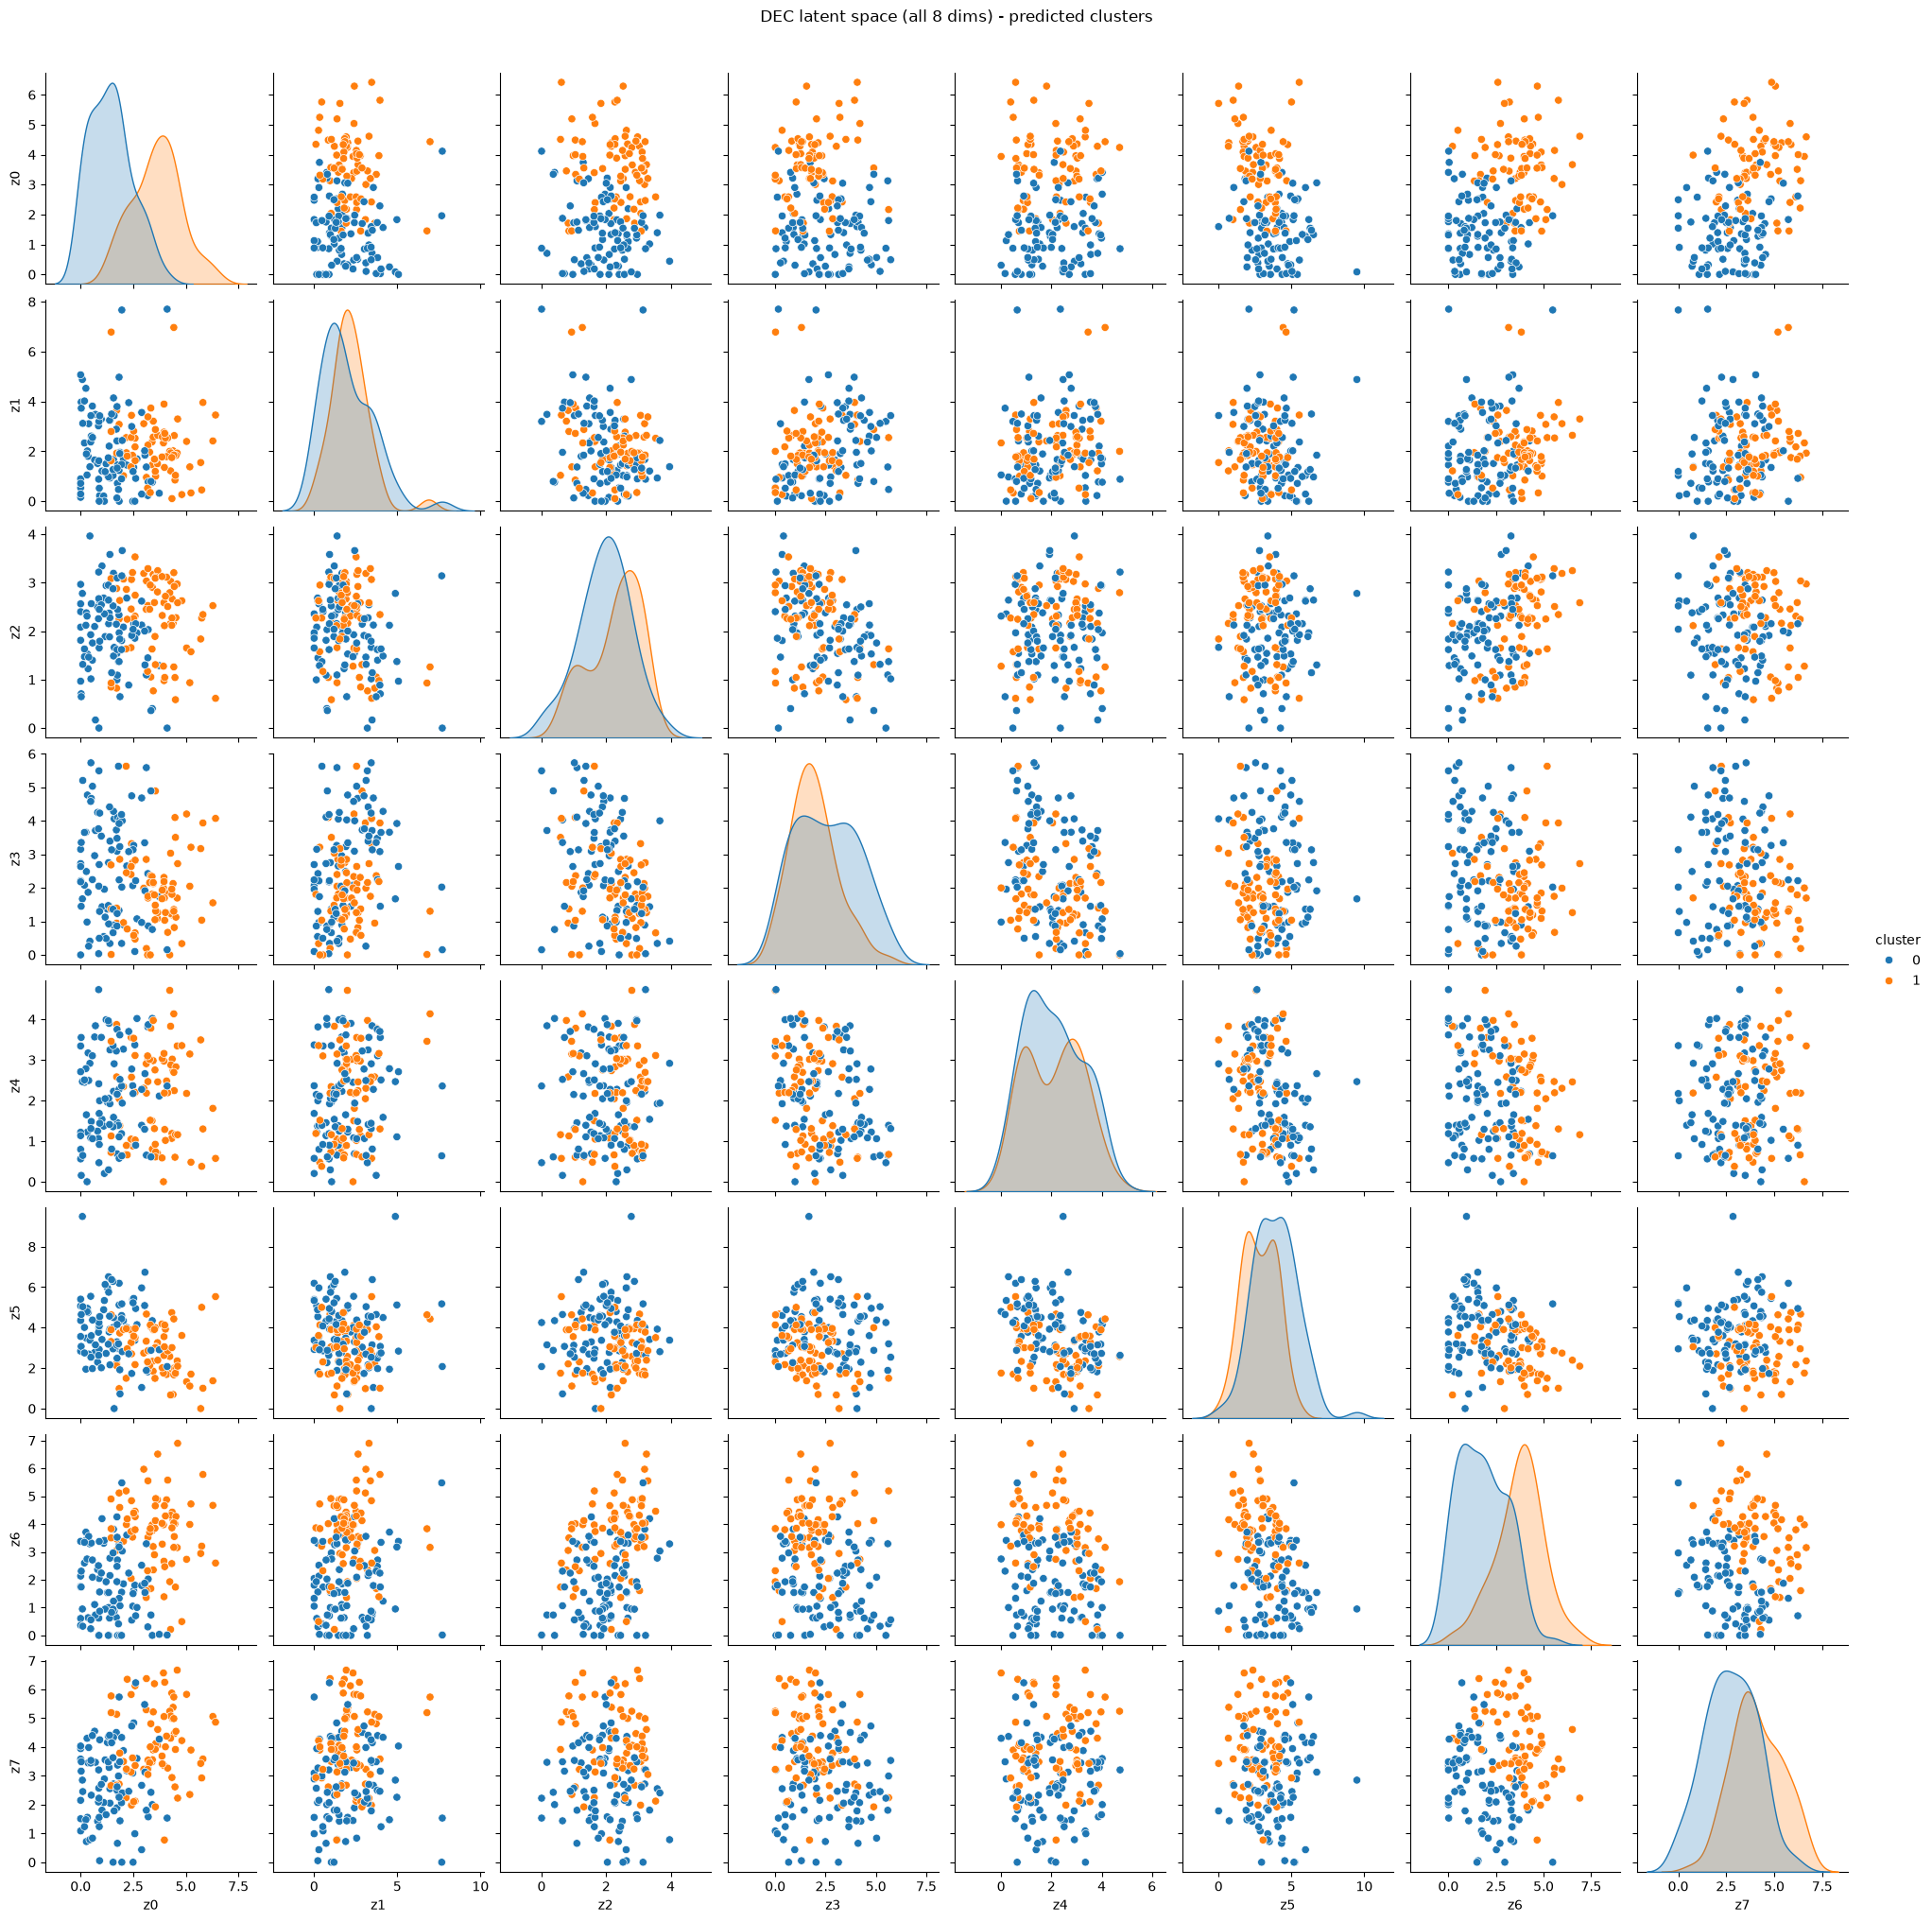

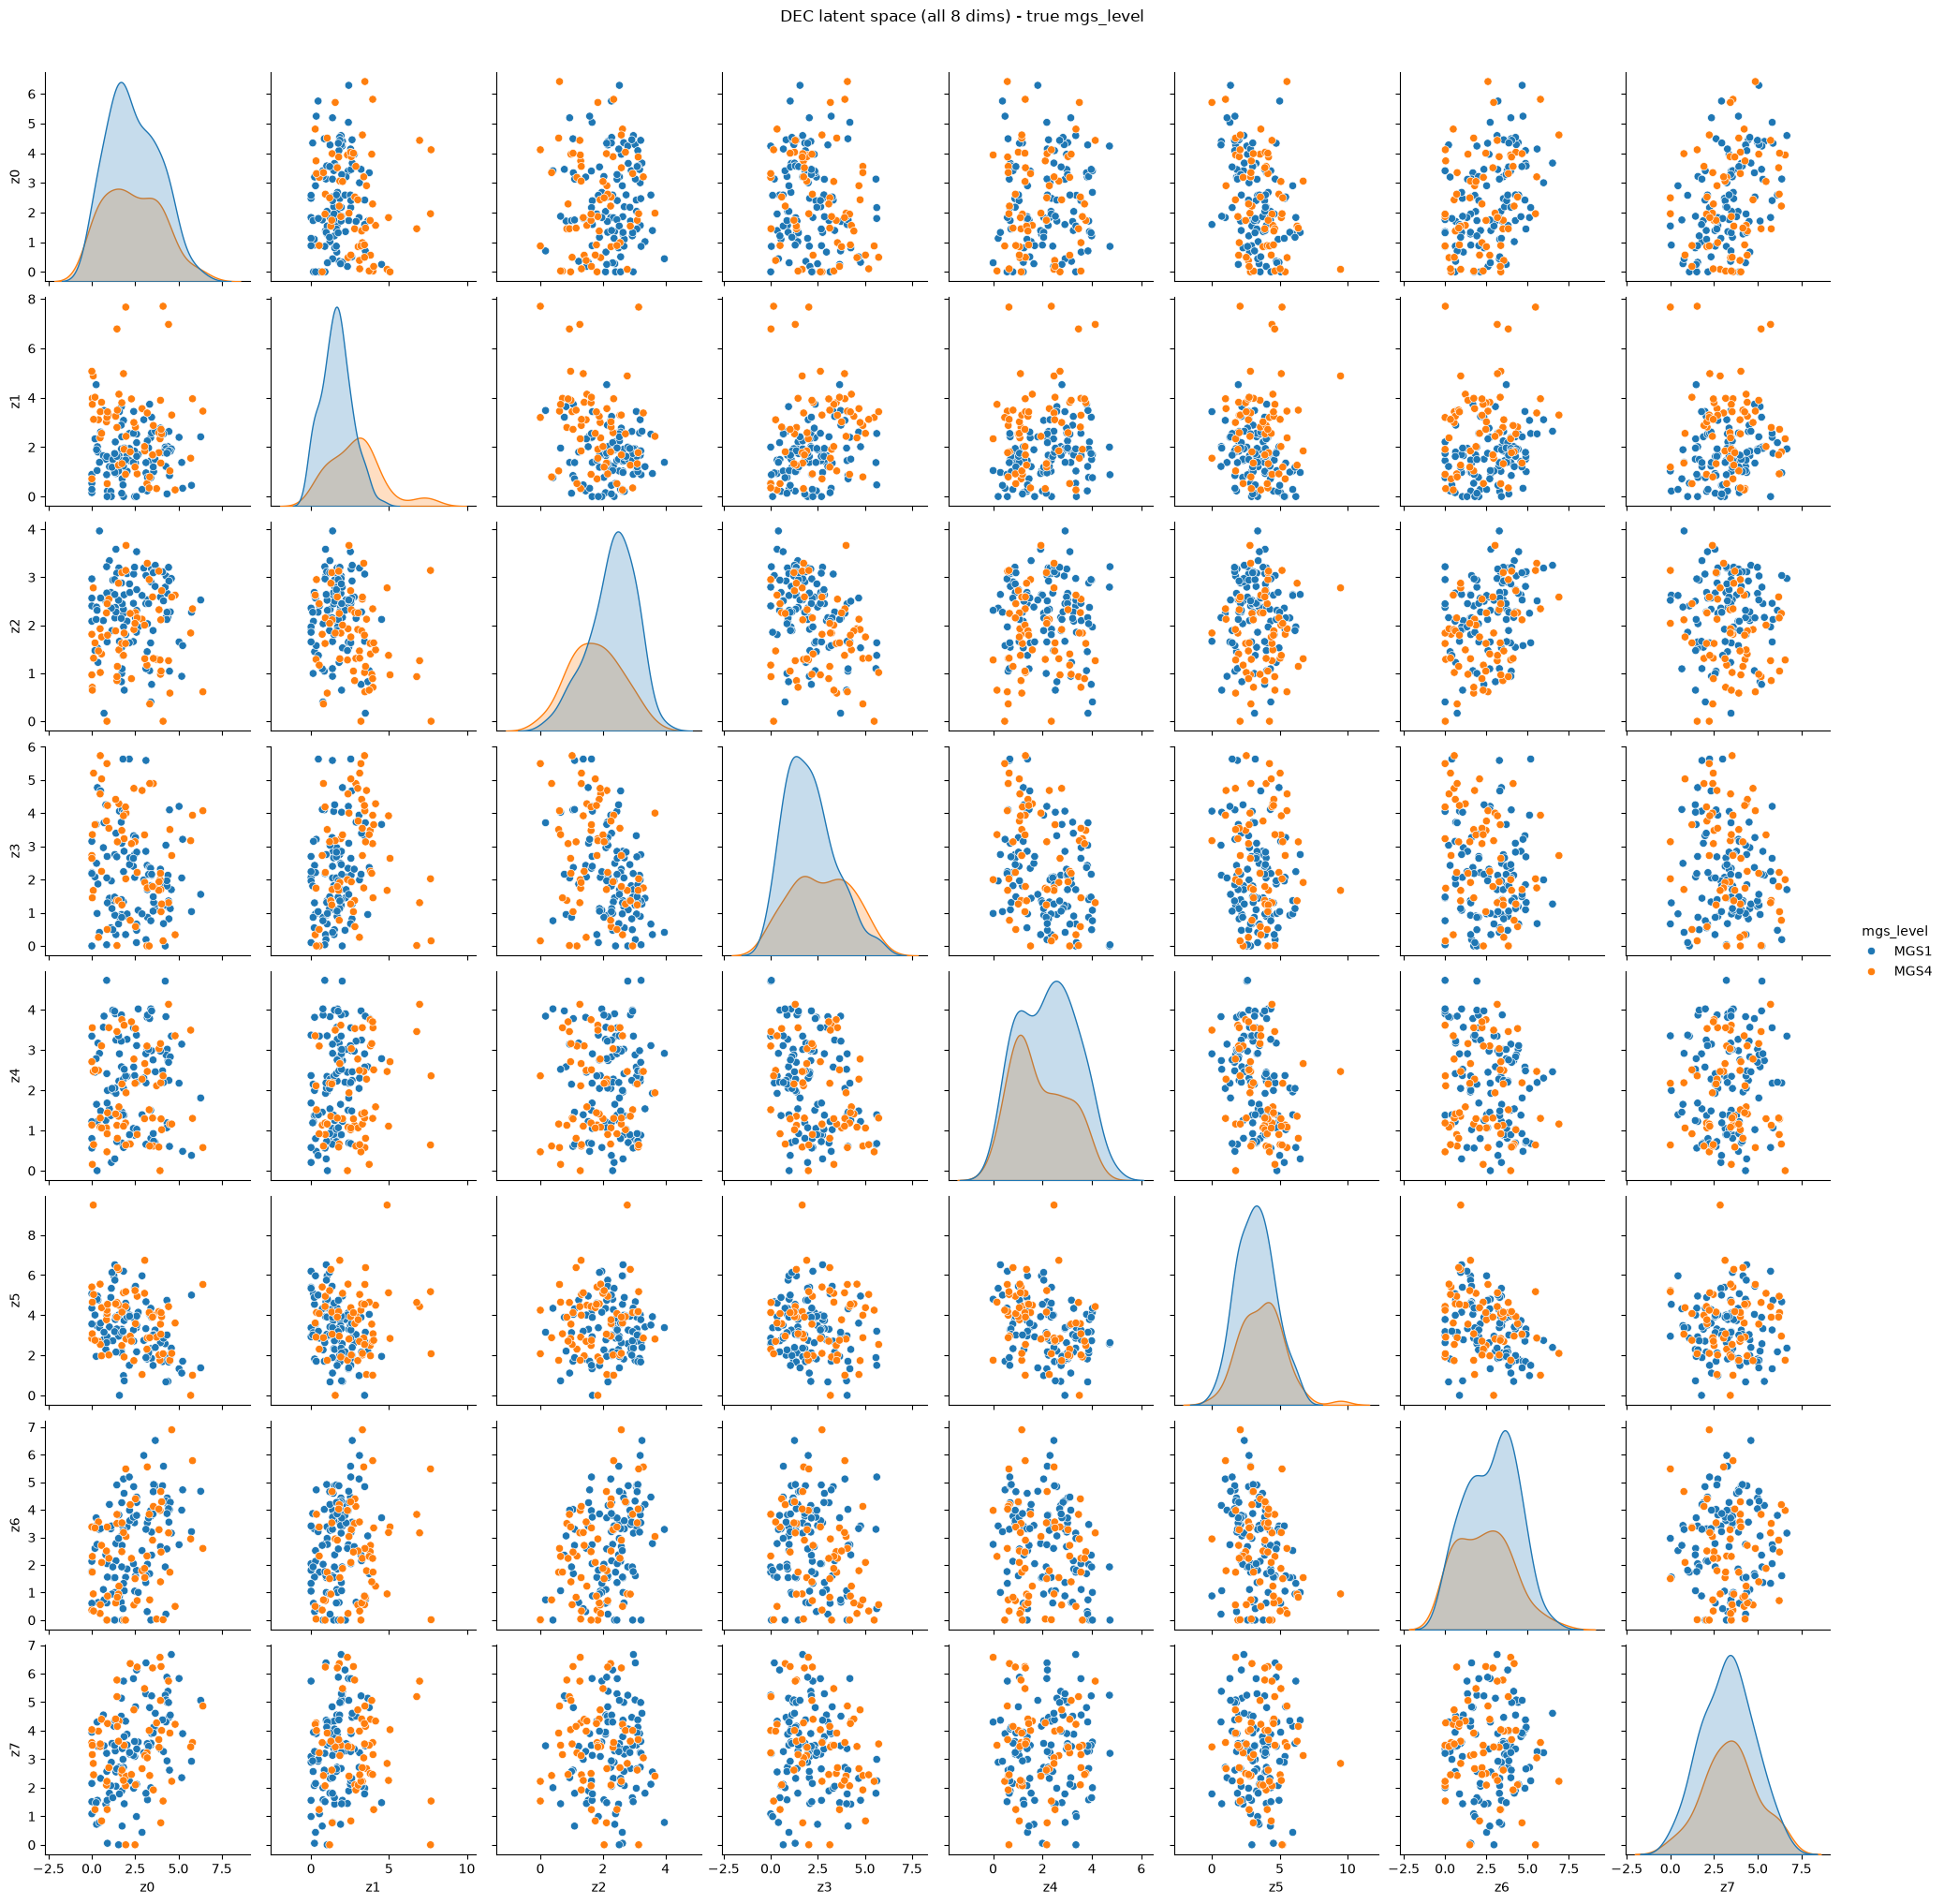

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

z_cols = [f'z{i}' for i in range(z.shape[1])]
z_df = pd.DataFrame(z, columns=z_cols)
z_df['cluster'] = y_pred.astype(str)
z_df['mgs_level'] = data['label_classes'][data['y']]

sns.pairplot(z_df, vars=z_cols, hue='cluster', palette='tab10')
plt.suptitle('DEC latent space (all {} dims) - predicted clusters'.format(z.shape[1]), y=1.02)
plt.show()

sns.pairplot(z_df, vars=z_cols, hue='mgs_level', palette='tab10')
plt.suptitle('DEC latent space (all {} dims) - true mgs_level'.format(z.shape[1]), y=1.02)
plt.show()

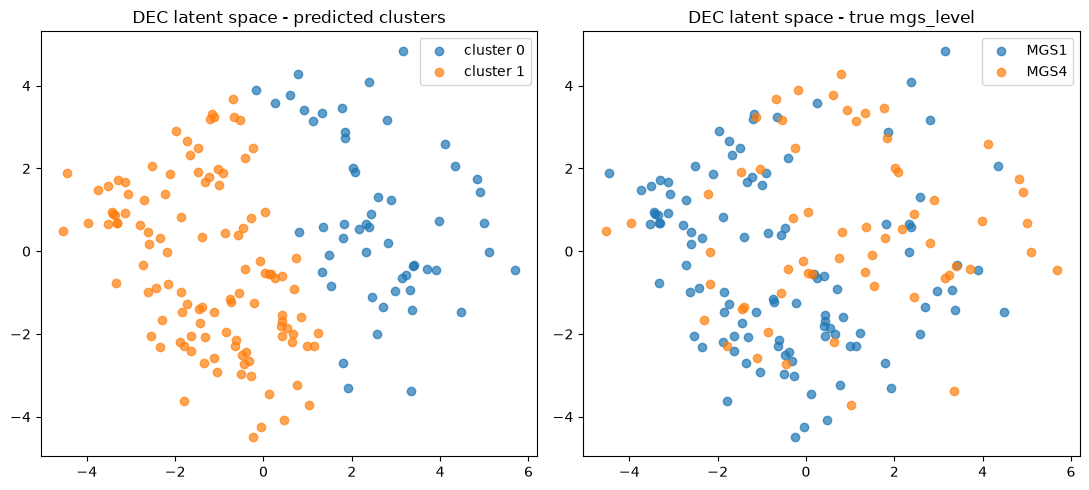

mgs_level  MGS1  MGS4
cluster              
0            21    33
1            84    28


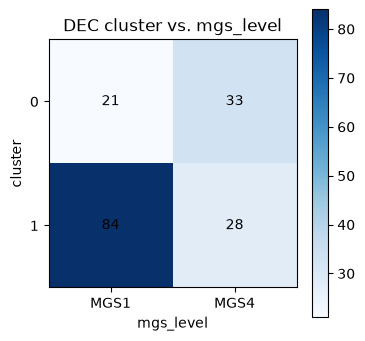

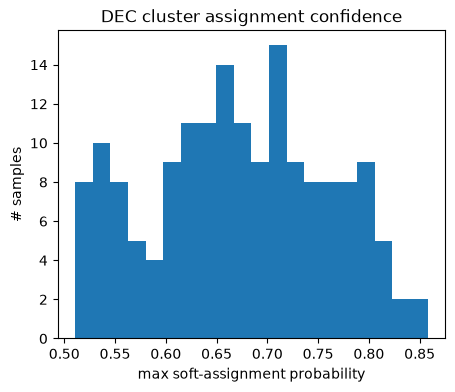

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA

# ---- 1. latent space, predicted cluster vs. true label ----
proj = PCA(n_components=4, random_state=5192).fit_transform(z)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for c in np.unique(y_pred):
    mask = y_pred == c
    axes[0].scatter(proj[mask, 0], proj[mask, 1], label=f'cluster {c}', alpha=0.7)
axes[0].set_title('DEC latent space - predicted clusters')
axes[0].legend()

for c, name in enumerate(data['label_classes']):
    mask = data['y'] == c
    axes[1].scatter(proj[mask, 0], proj[mask, 1], label=name, alpha=0.7)
axes[1].set_title('DEC latent space - true mgs_level')
axes[1].legend()
plt.tight_layout()
plt.show()

# ---- 2. cluster vs. label cross-tab heatmap ----
ct = pd.crosstab(pd.Series(y_pred, name='cluster'),
                 pd.Series(data['label_classes'][data['y']], name='mgs_level'))
print(ct)

fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(ct.values, cmap='Blues')
ax.set_xticks(range(len(ct.columns))); ax.set_xticklabels(ct.columns)
ax.set_yticks(range(len(ct.index))); ax.set_yticklabels(ct.index)
ax.set_xlabel('mgs_level'); ax.set_ylabel('cluster')
for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        ax.text(j, i, ct.values[i, j], ha='center', va='center')
plt.colorbar(im)
plt.title('DEC cluster vs. mgs_level')
plt.show()

# ---- 3. assignment confidence ----
plt.figure(figsize=(5, 4))
plt.hist(y_proba.max(axis=1), bins=20)
plt.xlabel('max soft-assignment probability')
plt.ylabel('# samples')
plt.title('DEC cluster assignment confidence')
plt.show()

In [1]:
import numpy as np
from misc.dataset import get_data
from misc.helpers import normalizeRNA
from models.autoencoder import MLPAutoencoder
from models.dec import DEC
from models.metrics import calculate_metrics

data = get_data(clin_file="C:/Users/Brayan Gutierrez/Desktop/RNAseq-AMD/Dataset/MetaSheet_1_4_17.csv", clinical_mode='full')  # loads + joins aak100_cpmdat.csv and MetaSheet_1_4.csv by sample_id
X = np.hstack([normalizeRNA(data['rnanp']), data['clin']]).astype(np.float32)
print(X.shape, data['label_classes'])

(166, 97) ['MGS1' 'MGS4']


In [2]:
# ---- Load a previously saved encoder checkpoint (not retrained) ----
from models.autoencoder import load_autoencoder

encoder_path = "C:/Users/Brayan Gutierrez/Desktop/RNAseq-AMD/DEC/results/manual_run_17_3/encoder_dec.pt"  # <- point this at a saved checkpoint
ae_loaded = load_autoencoder(encoder_path)  # build_model() + load_state_dict() + eval() already done
print('Loaded: neurons_h={} neurons_e={} l1_coef={} n_features={}'.format(
    ae_loaded.args.neurons_h, ae_loaded.args.neurons_e, ae_loaded.args.l1_coef, ae_loaded.args.n_features))

if ae_loaded.args.n_features != X.shape[1]:
    raise ValueError('Input width {} does not match checkpoint n_features {} - '
                      'check clinical_mode matches how this encoder was trained'.format(
                          X.shape[1], ae_loaded.args.n_features))

Loaded: neurons_h=64 neurons_e=4 l1_coef=0.0001 n_features=97


In [3]:
# ---- Cluster on top of the loaded encoder, WITHOUT retraining it ----
# models/dec.py's DEC in this copy is the frozen-encoder variant: it still
# runs the real K-means-init + Q/P self-training algorithm, it just never
# updates ae_loaded's weights - only the DECHead's cluster centers train.
from sklearn.metrics import adjusted_mutual_info_score

dec_frozen = DEC(ae_loaded, n_clusters=2)
y_pred_frozen, y_proba_frozen, centroids_frozen, z_frozen = dec_frozen.fit(X, y=data['y'])

acc, ari, nmi = calculate_metrics(data['y'], y_pred_frozen)
ami = adjusted_mutual_info_score(data['y'], y_pred_frozen)
print('acc={:.3f}  ari={:.3f}  nmi={:.3f}  ami={:.3f}'.format(acc, ari, nmi, ami))

Iter 0: acc = 0.56024, nmi = 0.01501, ari = 0.00870 ; loss=0.00000
Iter 140: acc = 0.56024, nmi = 0.01501, ari = 0.00870 ; loss=0.04194
delta_label 0.0 < tol 0.01
performed 140 iterations.
Reached tolerance threshold. Stopping training.
Final: acc = 0.56024, nmi = 0.01501, ari = 0.00870 ; loss=0.04194
acc=0.560  ari=0.009  nmi=0.015  ami=0.011
